# 02. Pipeline & Demand Score
> `01_EDA_and_Hypothesis.ipynb`에서 검증한 가설을 바탕으로
> `src/pipeline.py`의 `DemandForecastingPipeline`을 정적 CSV 데이터에 적용해
> 시군구별 인테리어 수요 점수를 산출하고 시각화한다.

| 단계 | 내용 |
|------|------|
| STEP 1 | 환경 설정 & 파이프라인 실행 |
| STEP 2 | 수요 점수 랭킹 시각화 |
| STEP 3 | 시도별 요약 |
| STEP 4 | 세그먼트 분포 시각화 |
| STEP 5 | 가중치 커스터마이징 실험 |
| STEP 6 | 결론 & 다음 단계 |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

from src.pipeline import DemandForecastingPipeline, SCORE_WEIGHTS

print('라이브러리 로드 완료 ✅')

라이브러리 로드 완료 ✅


## STEP 1. 파이프라인 실행

`DemandForecastingPipeline.run()`은 다음 순서로 동작한다.

`load_data()` → `preprocess_transactions()` → `preprocess_supply()` → `aggregate_and_merge()` → `calculate_demand_score()` → `get_results()`

In [2]:
TRANSACTIONS_PATH = "../data/아파트(매매)_실거래가_20260311170739.csv"
SUPPLY_PATH = "../data/한국부동산원_주택공급정보_입주예정물량정보_20251231.csv"

pipeline = DemandForecastingPipeline(
    transactions_path=TRANSACTIONS_PATH,
    supply_path=SUPPLY_PATH,
)

df_result, sido_summary = pipeline.run()

  오늘의집 인테리어 수요 예측 파이프라인 시작


[LOAD] CSV 로드: 79,591건
[LOAD] 입주예정 로드: 675건


[PREPROCESS] 실거래가 정제 완료: 79,591건
  세그먼트 분포:
세그먼트
Very_Old_Apartment    46588
Mid_Apartment         13866
Old_Apartment         10892
New_Apartment          8245
[PREPROCESS] 입주예정 정제 완료: 348건
[MERGE] 집계 완료: 25개 시군구
[SCORE] 수요 점수 계산 완료
  최고: 70.6 | 평균: 33.7


## STEP 2. 수요 점수 랭킹 시각화

전체 시군구 중 인테리어 수요 점수 TOP 10 지역을 확인한다.

In [3]:
top10 = df_result.head(10)
top10

,시도,시군구,거래건수,평균거래금액_만원,평균노후도_년,평균면적_m2,신규입주_세대수,입주단지수,인테리어_수요점수
14,서울,서초구,456,303250.4,18.0,111.8,5886.0,7.0,70.57
17,서울,송파구,1091,246816.4,17.7,86.8,2572.0,4.0,59.51
0,서울,강남구,525,287646.5,18.4,90.8,349.0,2.0,55.31
16,서울,성북구,1606,89845.4,17.9,79.0,856.0,3.0,48.48
5,서울,광진구,262,180260.0,18.2,108.3,828.0,3.0,45.65
20,서울,용산구,203,205295.1,18.0,105.1,0.0,0.0,43.17
3,서울,강서구,751,109232.6,18.3,80.1,1727.0,6.0,38.83
18,서울,양천구,345,118128.4,18.5,92.3,103.0,1.0,35.35
15,서울,성동구,294,152115.8,18.2,81.5,1936.0,2.0,34.86
19,서울,영등포구,254,141083.5,17.8,97.8,707.0,1.0,34.63


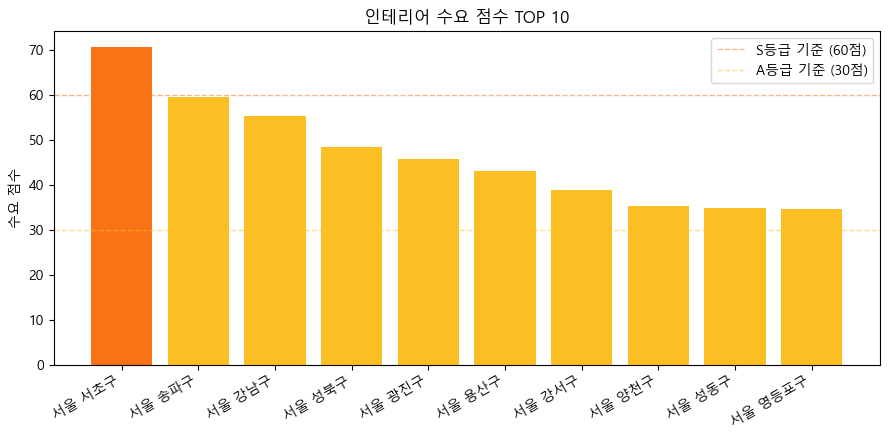

In [4]:
colors = ["#f97316" if s >= 60 else "#fbbf24" if s >= 30 else "#38bdf8" for s in top10["인테리어_수요점수"]]

plt.figure(figsize=(9, 4.5))
plt.bar(top10["시도"] + " " + top10["시군구"], top10["인테리어_수요점수"], color=colors)
plt.title("인테리어 수요 점수 TOP 10")
plt.ylabel("수요 점수")
plt.xticks(rotation=30, ha="right")
plt.axhline(60, color="#f97316", linestyle="--", linewidth=1, alpha=.5, label="S등급 기준 (60점)")
plt.axhline(30, color="#fbbf24", linestyle="--", linewidth=1, alpha=.5, label="A등급 기준 (30점)")
plt.legend()
plt.tight_layout()
plt.show()

## STEP 3. 시도별 요약

`get_results()`가 함께 반환하는 `sido_summary`로 시도 단위의 평균/최고 수요 점수를 비교한다.

In [5]:
sido_summary

,시도,시군구수,총거래건수,평균수요점수,최고수요점수,총신규입주
0,서울,25,10892,33.69,70.57,27158.0


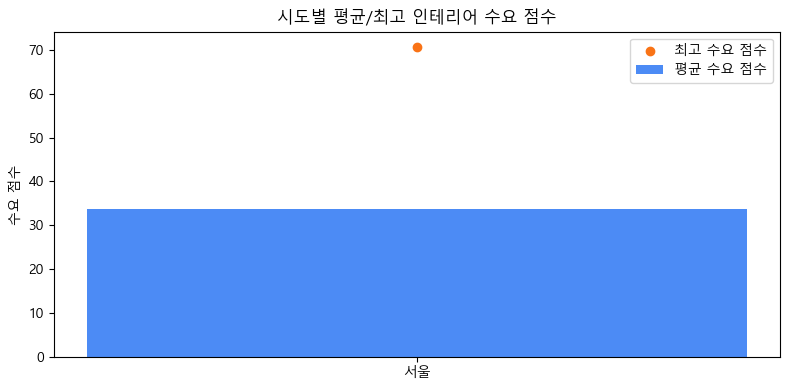

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(sido_summary["시도"], sido_summary["평균수요점수"], color="#4C8BF5", label="평균 수요 점수")
plt.scatter(sido_summary["시도"], sido_summary["최고수요점수"], color="#f97316", zorder=3, label="최고 수요 점수")
plt.title("시도별 평균/최고 인테리어 수요 점수")
plt.ylabel("수요 점수")
plt.legend()
plt.tight_layout()
plt.show()

## STEP 4. 세그먼트 분포 시각화

`preprocess_transactions()` 단계에서 분류된 아파트 세그먼트 분포를 확인한다.
(`pipeline.df_transactions`는 전처리된 전체 거래 데이터)

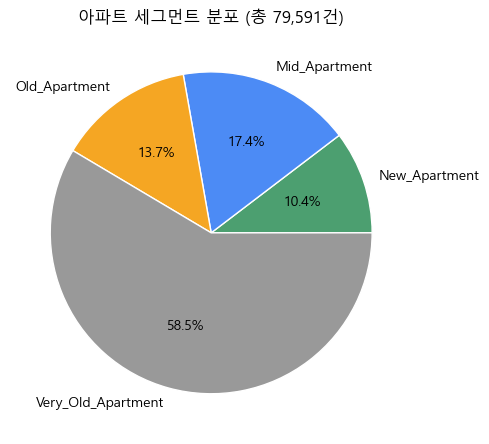

In [7]:
seg_order = ["New_Apartment", "Mid_Apartment", "Old_Apartment", "Very_Old_Apartment"]
colors_seg = ["#4C9F70", "#4C8BF5", "#F5A623", "#999999"]

seg_counts = pipeline.df_transactions["세그먼트"].value_counts().reindex(seg_order)

plt.figure(figsize=(5, 5))
plt.pie(
    seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
    colors=colors_seg, wedgeprops={"edgecolor": "white"}
)
plt.title(f"아파트 세그먼트 분포 (총 {seg_counts.sum():,}건)")
plt.tight_layout()
plt.show()

## STEP 5. 가중치 커스터마이징 실험

기본 가중치(`SCORE_WEIGHTS`)와, 신규 입주 수요를 더 중시하는 가중치를 비교해
랭킹이 어떻게 달라지는지 확인한다.

In [8]:
print("기본 가중치:", SCORE_WEIGHTS)

custom_weights = {
    "거래건수": 0.25,
    "거래금액": 0.20,
    "노후도":   0.15,
    "면적":     0.10,
    "신규입주": 0.30,  # 가중치 상향
}
print("커스텀 가중치:", custom_weights)

pipeline_custom = DemandForecastingPipeline(
    transactions_path=TRANSACTIONS_PATH,
    supply_path=SUPPLY_PATH,
    score_weights=custom_weights,
)

df_result_custom, _ = pipeline_custom.run()

기본 가중치: {'거래건수': 0.3, '거래금액': 0.25, '노후도': 0.2, '면적': 0.15, '신규입주': 0.1}
커스텀 가중치: {'거래건수': 0.25, '거래금액': 0.2, '노후도': 0.15, '면적': 0.1, '신규입주': 0.3}
  오늘의집 인테리어 수요 예측 파이프라인 시작


[LOAD] CSV 로드: 79,591건
[LOAD] 입주예정 로드: 675건


[PREPROCESS] 실거래가 정제 완료: 79,591건
  세그먼트 분포:
세그먼트
Very_Old_Apartment    46588
Mid_Apartment         13866
Old_Apartment         10892
New_Apartment          8245
[PREPROCESS] 입주예정 정제 완료: 348건
[MERGE] 집계 완료: 25개 시군구
[SCORE] 수요 점수 계산 완료
  최고: 76.1 | 평균: 30.0


In [9]:
compare = pd.merge(
    df_result[["시도", "시군구", "인테리어_수요점수"]].reset_index(drop=True).reset_index().rename(columns={"index": "기본_순위", "인테리어_수요점수": "기본_점수"}),
    df_result_custom[["시도", "시군구", "인테리어_수요점수"]].reset_index(drop=True).reset_index().rename(columns={"index": "커스텀_순위", "인테리어_수요점수": "커스텀_점수"}),
    on=["시도", "시군구"],
)
compare["기본_순위"] += 1
compare["커스텀_순위"] += 1
compare["순위변화"] = compare["기본_순위"] - compare["커스텀_순위"]

compare.sort_values("순위변화", ascending=False).head(10)

,기본_순위,시도,시군구,기본_점수,커스텀_순위,커스텀_점수,순위변화
20,21,서울,은평구,22.53,14,26.79,7
19,20,서울,중랑구,23.34,16,25.01,4
22,23,서울,구로구,21.29,21,19.25,2
16,17,서울,동대문구,27.01,15,26.26,2
8,9,서울,성동구,34.86,7,34.19,2
13,14,서울,동작구,29.15,12,27.36,2
10,11,서울,마포구,34.60,9,30.77,2
6,7,서울,강서구,38.83,6,36.91,1
11,12,서울,강동구,32.99,11,28.20,1
0,1,서울,서초구,70.57,1,76.12,0


**관찰:** 신규입주 가중치를 30%로 높이면, 입주예정 물량이 많은 시군구의 순위가 상승하는 것을 확인할 수 있다.
이처럼 `score_weights` 파라미터만 바꾸면 비즈니스 전략(예: 신규 입주 세대 마케팅 강화)에 맞춰
손쉽게 결과를 재산출할 수 있다.

## STEP 6. 결론 & 다음 단계

- `DemandForecastingPipeline.run()`으로 실거래가 + 입주예정 데이터를 결합해
  시군구별 인테리어 수요 점수와 시도별 요약을 한 번에 산출했다.
- TOP 10 랭킹, 세그먼트 분포, 시도별 비교를 통해 `01_EDA_and_Hypothesis.ipynb`에서 세운 가설
  (Old_Apartment 핵심 타겟, 가중치 구성)이 실제 결과에서도 유효함을 확인했다.
- 가중치를 변경한 비교 실험을 통해, 비즈니스 전략 변화에 따라 결과가 어떻게 달라지는지 검증했다.

### 다음 단계
- `notebooks/03_API_Collection.ipynb`에서 공공데이터 API로 최신 데이터를 수집해 동일한 파이프라인에 연결
- `app.py`(Flask) → `/api/demand`로 결과를 대시보드에 제공